# DBSCAN con el dataset NYPD Arrest Data

Completa las celdas para aplicar **DBSCAN** a este dataset real del NYPD.

## Pasos
- Preparar el dataset.
- Seleccionar las variables adecuadas.
- Escalar los datos.
- Aplicar DBSCAN.
- Interpretar los clusters y el ruido.
>**Nota**: Las celdas que contiene el NOtebook son orientativas. Puedes modificarlas si fuese necesario en tu desarrollo.

In [71]:
# Si tu entorno no tiene instaladas estas librerías, descomenta la línea siguiente:
# !pip install pandas numpy matplotlib scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

## 1. Carga del dataset

In [72]:
ruta = 'NYPD_Arrest_Data__Year_to_Date_.csv'
# Completa la lectura del CSV
df = pd.read_csv(ruta)

# Muestra sus dimensiones y las primeras filas
print(df.shape)
df.head(5)

(278953, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


## 2. Exploración inicial

In [73]:
# Muestra los nombres de las columnas
df.info()
# Comprueba si hay valores nulos en Latitude y Longitude
df[["Latitude", "Longitude"]].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

Latitude     0
Longitude    0
dtype: int64

## 3. Selección de variables

Vas a trabajar con variables que estimes que pueden ser útiles en **DBSCAN**.

In [74]:
# Crea un nuevo DataFrame con las variables decididas
datos = df[["Latitude", "Longitude", "AGE_GROUP", "PERP_SEX", "PERP_RACE", "OFNS_DESC"]].copy()

# Elimina los valores nulos
datos.dropna(inplace=True)
# Muestra cuántos registros quedan
print(datos.shape)

(278953, 6)


## 4. Toma una muestra

In [75]:
# Toma una muestra aleatoria de 15000 -te recomiendo que al finalizar hagas otras pruebas- registros con random_state=42
datos = datos.sample(n=15000, random_state=42)

# Muestra su tamaño
datos.shape

(15000, 6)

## 5. Visualización inicial

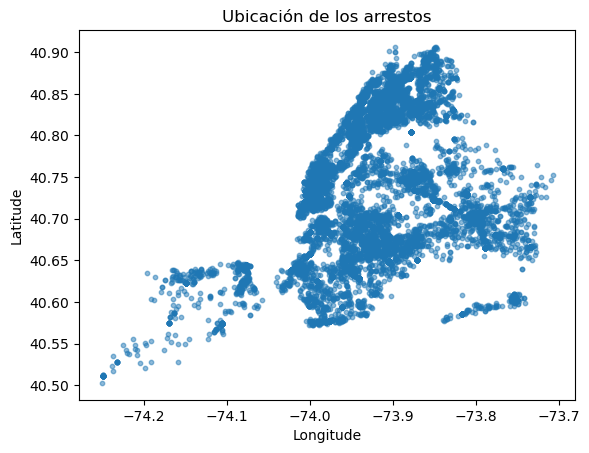

In [76]:
# Dibuja un scatter plot con:
X = datos[["Longitude", "Latitude"]]
y = datos["OFNS_DESC"]

plt.scatter(X["Longitude"], X["Latitude"], s=10, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Ubicación de los arrestos")
plt.show()

## 6. Escalado

In [77]:
# Crea el escalador
scaler = StandardScaler()

X = scaler.fit_transform(X)

## 7. Orientación para elegir eps

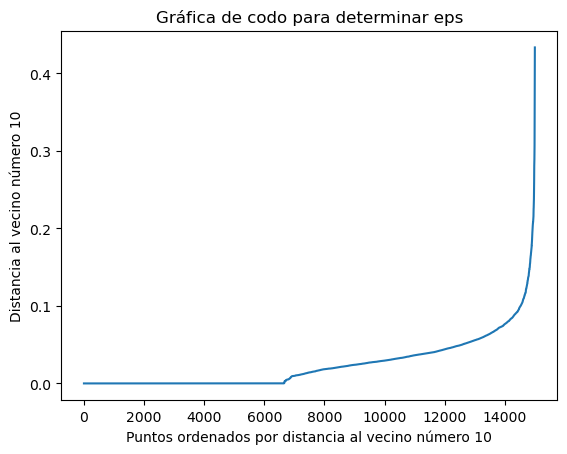

In [78]:
min_samples = 10

vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos.fit(X)

distancias, indices = vecinos.kneighbors(X)

# Tomamos la distancia al k-ésimo vecino
distancias_k = distancias[:, min_samples - 1]

# Ordenamos las distancias de menor a mayor
distancias_k = np.sort(distancias_k)

# Graficamos
plt.plot(distancias_k)
plt.xlabel(f"Puntos ordenados por distancia al vecino número {min_samples}")
plt.ylabel(f"Distancia al vecino número {min_samples}")
plt.title("Gráfica de codo para determinar eps")
plt.show()

## 8. Aplicación de DBSCAN

In [79]:
# Crea el modelo DBSCAN con un eps inicial razonable (no olvides justificar)
modelo = DBSCAN(eps=0.3, min_samples=min_samples)

# Entrena el modelo y obtén las etiquetas
clusters = modelo.fit_predict(X)

# Añade la columna cluster a la muestra
datos["cluster"] = clusters

In [80]:
# Calcula:
# - número de clusters (sin contar el ruido)
numero_clusters = len(set(clusters))
print("Número de clusters:", numero_clusters)

# - número de puntos ruido
numero_ruido = list(clusters).count(-1)
print("Número de puntos de ruido:", numero_ruido)

# - tamaño de cada etiqueta
tamaños = [list(clusters).count(i) for i in set(clusters) if i != -1]
print("Tamaños de los clusters:", tamaños)


Número de clusters: 3
Número de puntos de ruido: 0
Tamaños de los clusters: [14176, 195, 629]


## 9. Visualización final

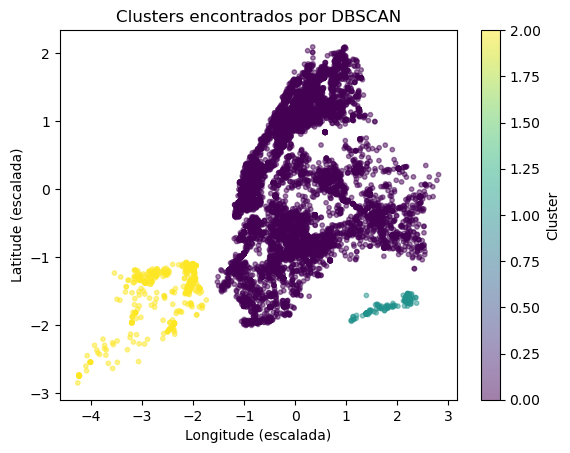

In [81]:
# Representa los puntos preferentemente en distinto color según el cluster encontrado
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=10, alpha=0.5, cmap='viridis')
plt.xlabel("Longitude (escalada)")
plt.ylabel("Latitude (escalada)")
plt.title("Clusters encontrados por DBSCAN")
plt.colorbar(label='Cluster')
plt.show()

## 10. Interpretación

Responde brevemente:

1. ¿Qué significa la etiqueta `-1`?
2. ¿Por qué DBSCAN puede detectar ruido y K-Means no?
3. ¿Qué pasa si `eps` es demasiado pequeño?
4. ¿Qué pasa si `eps` es demasiado grande?
5. ¿Por qué este dataset es más adecuado para DBSCAN que otros más simples?

## 11. Opcional

Prueba una de estas ampliaciones:
- Compara con K-Means.
- Usa una muestra más grande.
- Analiza sólo un tipo de delito.

In [122]:
#df_kmeans = df.sample(n=100000, random_state=42).copy()
df_kmeans = df.copy()

# Filtrar en base a género y raza, al igual que podemos verlo en base a los delitos
df_kmeans = df_kmeans[df_kmeans["PERP_SEX"] == "M"]
#df_kmeans = df_kmeans[df_kmeans["PERP_RACE"] == "BLACK"]
#df_kmeans = df_kmeans[(df_kmeans["OFNS_DESC"] == "ASSAULT 3 & RELATED OFFENSES")]

df_kmeans.dropna(inplace=True)
print(df_kmeans.shape)

# Selecciono X y lo escalo para KMeans, para filtrar en base a delitos
X_kmeans = df_kmeans[["Longitude", "Latitude"]]
y_kmeans = df_kmeans["OFNS_DESC"]

X_kmeans = scaler.fit_transform(X_kmeans)

(107493, 19)


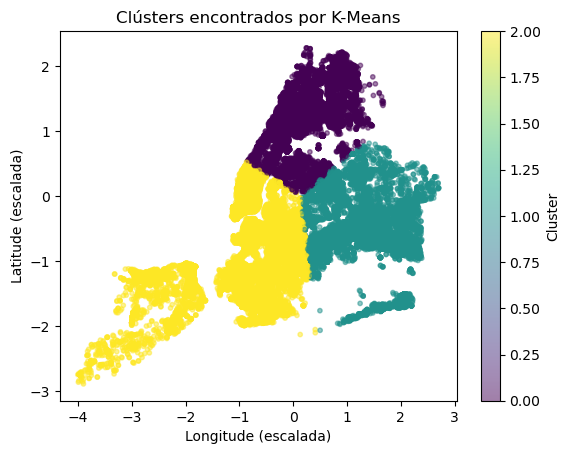

In [119]:
# Probando con el modelo de K-Means filtrando por género, raza y delito
from sklearn.cluster import KMeans

# Creando el modelo de KMeans
k_means = KMeans(n_clusters=numero_clusters, random_state=42)
clusters_kmeans = k_means.fit_predict(X_kmeans)

# Ahora voy a representar los clusters encontrados por K-Means para poder compararlos con DBSCAN
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=clusters_kmeans, s=10, alpha=0.5, cmap='viridis')
plt.xlabel("Longitude (escalada)")
plt.ylabel("Latitude (escalada)")
plt.title("Clústers encontrados por K-Means")
plt.colorbar(label='Cluster')
plt.show()

Número de clusters: 5


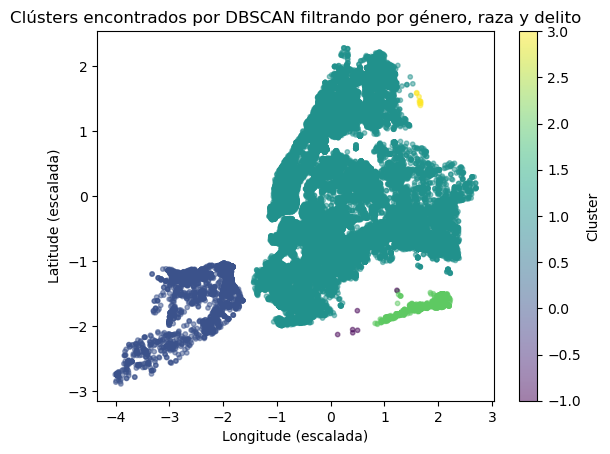

In [127]:
# Haciendo DBSCAN filtrando por género, raza y delito
modelo_dbscan_filtrado = DBSCAN(eps=0.2, min_samples=min_samples)
clusters_dbscan_filtrado = modelo_dbscan_filtrado.fit_predict(X_kmeans)

numero_clusters = len(set(clusters_dbscan_filtrado))
print("Número de clusters:", numero_clusters)

# Representando los clusters encontrados por DBSCAN filtrando por género, raza y delito
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=clusters_dbscan_filtrado, s=10, alpha=0.5, cmap='viridis')
plt.xlabel("Longitude (escalada)")
plt.ylabel("Latitude (escalada)")
plt.title("Clústers encontrados por DBSCAN filtrando por género, raza y delito")
plt.colorbar(label='Cluster')
plt.show()